# `GEA` dataset evaluation — IBD cohort exploratory data analysis

Before trusting any result from the GEA pipeline in
[`tutorial-ibd.ipynb`](tutorial-ibd.ipynb), we need to know whether the underlying data
can actually support the two learning tasks it is asked to do. This notebook answers two
questions:

1. **Is the gene-expression data good enough to train a classifier / regressor?**
   → cohort composition, technical confounding, QC, unsupervised structure, differential
   expression, and a *baseline* classifier that establishes the signal floor the GNN must beat.

2. **Are the sample-specific (LIONESS) networks suitable for training the GNN?**
   → graph statistics, node-feature audit, topology, how discriminative the networks are on
   their own, and a check for **label leakage** introduced by building networks per phenotype group.

The notebook is **read-only** with respect to the pipeline: it consumes the artefacts the
tutorial already produced (`data/tutorial-ibd-matrix.tsv`, `data/tutorial-ibd-metadata.txt`,
`data/ibd_graphs.pt`) and never retrains anything. Run it with the `gea` environment.

## Setup & data loading

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
RNG = 42
np.random.seed(RNG)

# Consistent phenotype palette used throughout
PHENO = {0: "CD", 1: "UC", 2: "non-IBD"}          # matches sorted(source_name) label map
PAL   = {"CD": "#d1495b", "UC": "#edae49", "non-IBD": "#30638e"}
pd.set_option("display.width", 120)

In [2]:
from gea.dataloader import load_counts, load_metadata

DATA = "data"

# 1. Raw count matrix — genes (Ensembl) × samples (BioSample)
raw_counts = load_counts(f"{DATA}/tutorial-ibd-matrix.tsv", delim="\t", index_col="Geneid")

# 2. Sample metadata
metadata = load_metadata(f"{DATA}/tutorial-ibd-metadata.txt", delim=",", index_col=None)

# 3. The graphs actually fed to the GNN (built by the tutorial). These are the
#    single source of truth for which samples/labels are modelled, so we derive
#    the canonical sample list and labels from them rather than re-parsing metadata.
graphs = torch.load(f"{DATA}/ibd_graphs.pt", weights_only=False)

# 4. Final modelled gene set (survivors of protein-coding + CPM/var + PPI filters)
modelled_genes = [l.strip() for l in open(f"{DATA}/ensembl_ids.txt") if l.strip()]

print(f"Raw matrix        : {raw_counts.shape[0]:>6} genes × {raw_counts.shape[1]:>3} samples")
print(f"Modelled genes    : {len(modelled_genes):>6}")
print(f"Graphs (samples)  : {len(graphs):>6}")

Raw matrix        :  60664 genes × 322 samples
Modelled genes    :   1165
Graphs (samples)  :    303


In [3]:
# Canonical sample → label table, taken from the graph objects
samples = [g.sample_name for g in graphs]
y       = np.array([g.y.item() for g in graphs])
pheno   = np.array([PHENO[v] for v in y])

meta = metadata.set_index("BioSample").loc[samples].copy()
meta["pheno"] = pheno
meta["depth"] = raw_counts[samples].sum(axis=0).values   # library size (total reads)

sample_df = pd.DataFrame({"sample": samples, "y": y, "pheno": pheno}).set_index("sample")
sample_df.head()

,y,pheno
sample,,
SAMN03322987,0,CD
SAMN03323176,0,CD
SAMN03323174,0,CD
SAMN03323029,0,CD
SAMN03323141,0,CD


---
# 1. Is the gene-expression data good enough for a classifier / regressor?

## 1.1. Cohort composition & class balance

The very first thing that governs whether a classifier can be trained well is how many
samples exist per class.

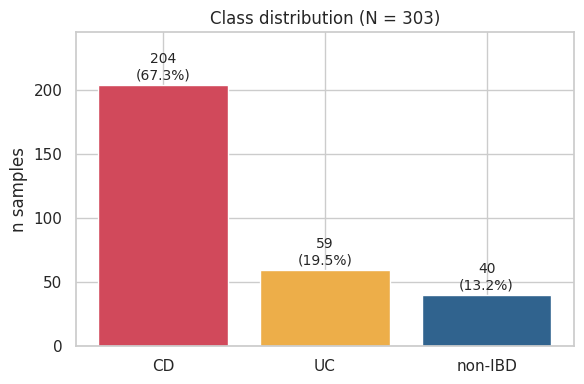

Imbalance ratio (majority/minority): 5.1×
A trivial 'always-CD' baseline would score 67.3% accuracy but 0% recall on UC and non-IBD.


In [4]:
counts = sample_df["pheno"].value_counts().reindex(["CD", "UC", "non-IBD"])
frac   = (counts / counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=[PAL[k] for k in counts.index])
for b, n, f in zip(bars, counts.values, frac.values):
    ax.text(b.get_x()+b.get_width()/2, n+2, f"{n}\n({f}%)", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("n samples"); ax.set_title(f"Class distribution (N = {counts.sum()})")
ax.set_ylim(0, counts.max()*1.2)
plt.tight_layout(); plt.show()

imb = counts.max() / counts.min()
print(f"Imbalance ratio (majority/minority): {imb:.1f}×")
print(f"A trivial 'always-CD' baseline would score {frac.max():.1f}% accuracy "
      f"but 0% recall on UC and non-IBD.")

> **Read-out.** N = 303 with a **≈5× class imbalance** (CD ≫ UC > non-IBD, only ~40 controls).
> This is the single biggest constraint on the expression task: accuracy is a misleading
> metric here, models must use class weighting / stratification, and every split must be
> stratified. It does not disqualify the data, but it dictates *how* we should evaluate.

## 1.2. Cohort homogeneity — is phenotype confounded with a technical variable?

The nightmare scenario for a biological classifier is that the label is secretly encoded by
a batch/technical variable (e.g. all controls sequenced on a different machine). If so, the
model learns the batch, not the biology. We cross-tabulate phenotype against every technical
field and compare sequencing depth / age across groups.

In [5]:
tech_cols = ["Instrument", "Center Name", "tissue", "LibraryLayout", "sex", "Platform"]
for c in [c for c in tech_cols if c in meta.columns]:
    ct = pd.crosstab(meta[c], meta["pheno"]).reindex(columns=["CD","UC","non-IBD"])
    print(f"— {c} —")
    print(ct.to_string(), "\n")

— Instrument —
pheno                 CD  UC  non-IBD
Instrument                           
Illumina HiSeq 2000  204  59       40 

— Center Name —
pheno         CD  UC  non-IBD
Center Name                  
GEO          204  59       40 

— tissue —
pheno          CD  UC  non-IBD
tissue                        
Ileal biopsy  204  59       40 

— LibraryLayout —
pheno           CD  UC  non-IBD
LibraryLayout                  
SINGLE         204  59       40 

— sex —
pheno    CD  UC  non-IBD
sex                     
female   89  25       15
male    115  34       25 

— Platform —
pheno      CD  UC  non-IBD
Platform                  
ILLUMINA  204  59       40 



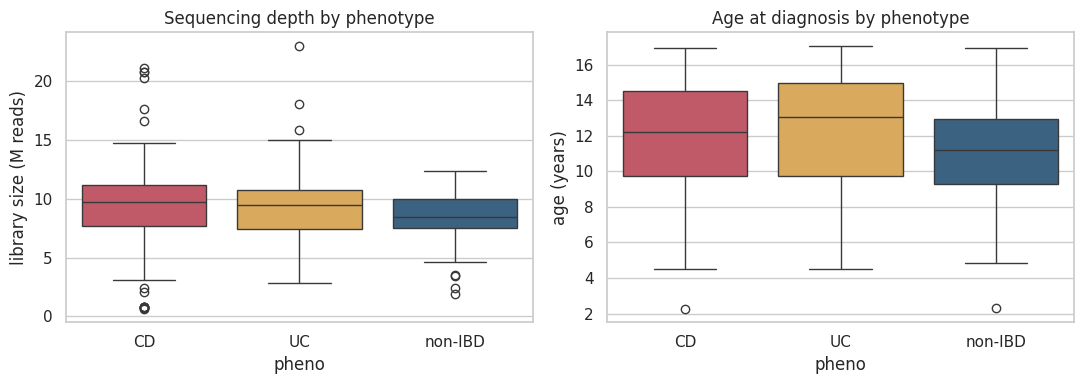

Median depth (M) by group:
 pheno
CD         9.8
UC         9.5
non-IBD    8.4

Median age by group:
 pheno
CD         12.2
UC         13.1
non-IBD    11.2


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
meta["depth_M"] = meta["depth"] / 1e6
sns.boxplot(data=meta, x="pheno", y="depth_M", order=["CD","UC","non-IBD"],
            palette=PAL, ax=axes[0])
axes[0].set_title("Sequencing depth by phenotype"); axes[0].set_ylabel("library size (M reads)")

age = pd.to_numeric(meta.get("age_at_diagnosis"), errors="coerce")
meta["age"] = age
sns.boxplot(data=meta, x="pheno", y="age", order=["CD","UC","non-IBD"],
            palette=PAL, ax=axes[1])
axes[1].set_title("Age at diagnosis by phenotype"); axes[1].set_ylabel("age (years)")
plt.tight_layout(); plt.show()

print("Median depth (M) by group:\n", meta.groupby("pheno")["depth_M"].median().round(1).to_string())
print("\nMedian age by group:\n", meta.groupby("pheno")["age"].median().round(1).to_string())

> **Read-out.** The cohort is remarkably homogeneous: a **single instrument, single
> center, single tissue (treatment-naïve ileal biopsy), single library layout**, with
> comparable sequencing depth and age across groups and a roughly balanced sex ratio.
> There is **no obvious technical confounder** for the classifier to shortcut on — any signal
> it finds is far more likely to be biological. (This is the paediatric RISK Crohn's cohort.)

## 1.3. Sequencing-depth & gene-detection QC

Per-sample QC catches degenerate samples (very low depth, few genes detected) that would add
noise. We look at library size and the number of genes detected per sample.

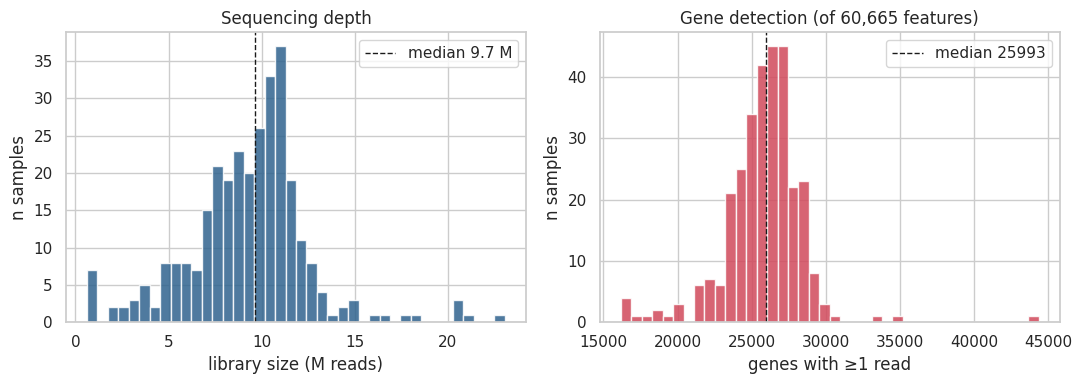

Library size  : min 0.6 M, median 9.7 M, max 23.1 M
Depth spread  : max/min = 37.1×
Genes detected: min 16171, median 25993


In [7]:
lib = raw_counts[samples].sum(axis=0)
genes_detected = (raw_counts[samples] > 0).sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(lib/1e6, bins=40, color="#30638e", alpha=0.85)
axes[0].axvline((lib/1e6).median(), color="k", ls="--", lw=1,
                label=f"median {(lib/1e6).median():.1f} M")
axes[0].set_xlabel("library size (M reads)"); axes[0].set_ylabel("n samples")
axes[0].set_title("Sequencing depth"); axes[0].legend()

axes[1].hist(genes_detected, bins=40, color="#d1495b", alpha=0.85)
axes[1].axvline(genes_detected.median(), color="k", ls="--", lw=1,
                label=f"median {int(genes_detected.median())}")
axes[1].set_xlabel("genes with ≥1 read"); axes[1].set_ylabel("n samples")
axes[1].set_title("Gene detection (of 60,665 features)"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Library size  : min {lib.min()/1e6:.1f} M, median {lib.median()/1e6:.1f} M, max {lib.max()/1e6:.1f} M")
print(f"Depth spread  : max/min = {lib.max()/lib.min():.1f}×")
print(f"Genes detected: min {genes_detected.min()}, median {int(genes_detected.median())}")

> **Read-out.** Depth is tight (see max/min ratio printed above) with no near-empty samples,
> and gene detection is consistent. No sample needs to be dropped for QC reasons.

## 1.4. Gene-filtering funnel

The pipeline reduces 60,665 raw features to the 1,165 genes that become graph nodes. The
protein-coding and PPI-intersection steps require network calls (mygene / STRING), so here we
reproduce the two *purely computational* filters live — CPM abundance and variance — to show
their magnitude, and report the documented endpoints of the full funnel.

                                                stage  n_genes
                                         raw features    60664
                               CPM ≥1 in ≥10% samples    18569
                                   + top-10% variance     1857
protein-coding ∩ CPM/var ∩ PPI (final, from artefact)     1165


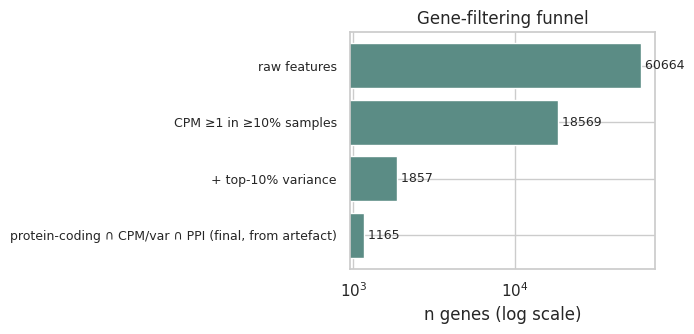

In [8]:
from gea.preprocessing import filter_cpm, filter_var

n_raw = raw_counts.shape[0]
after_cpm = filter_cpm(raw_counts, cpm_threshold=1.0, min_frac=0.1)
after_var = filter_var(after_cpm, pct=0.1)

funnel = pd.DataFrame({
    "stage": ["raw features",
              "CPM ≥1 in ≥10% samples",
              "+ top-10% variance",
              "protein-coding ∩ CPM/var ∩ PPI (final, from artefact)"],
    "n_genes": [n_raw, after_cpm.shape[0], after_var.shape[0], len(modelled_genes)],
})
print(funnel.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(range(len(funnel))[::-1], funnel["n_genes"], color="#5b8c85")
ax.set_yticks(range(len(funnel))[::-1]); ax.set_yticklabels(funnel["stage"], fontsize=9)
ax.set_xlabel("n genes (log scale)"); ax.set_xscale("log")
for i, v in enumerate(funnel["n_genes"][::-1]):
    ax.text(v, i, f" {v}", va="center", fontsize=9)
ax.set_title("Gene-filtering funnel"); plt.tight_layout(); plt.show()

> **Read-out.** Aggressive but standard filtering. The final 1,165 genes are the
> highly-expressed, high-variance, protein-coding genes that also have a STRING partner —
> exactly the set most likely to carry disease signal, and small enough to keep the graphs
> tractable.

## 1.5. Building the modelled expression matrix

For everything that follows we work with the log₂(CPM+1) matrix restricted to the 1,165
modelled genes and the 303 modelled samples — i.e. the *node-expression* information the GNN
actually sees.

Expression matrix X: (303, 1165)  (samples × modelled genes)


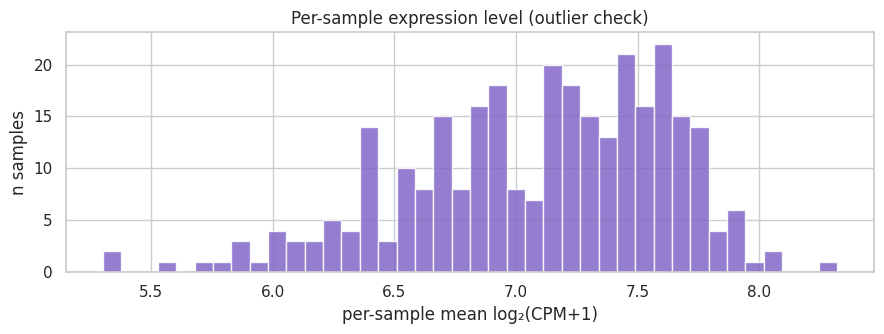

In [9]:
genes = [g for g in modelled_genes if g in raw_counts.index]
sub   = raw_counts.loc[genes, samples]
libM  = sub.sum(axis=0)
logcpm = np.log2(sub.div(libM, axis=1) * 1e6 + 1.0).T      # samples × genes
X = logcpm.values
print(f"Expression matrix X: {X.shape}  (samples × modelled genes)")

fig, ax = plt.subplots(figsize=(9, 3.5))
# density of per-sample mean log-CPM to check for outlier samples
ax.hist(X.mean(axis=1), bins=40, color="#8367c7", alpha=0.85)
ax.set_xlabel("per-sample mean log₂(CPM+1)"); ax.set_ylabel("n samples")
ax.set_title("Per-sample expression level (outlier check)")
plt.tight_layout(); plt.show()

## 1.6. Unsupervised structure — does phenotype drive expression variance?

If the phenotype is a major axis of variation, an unsupervised PCA/UMAP will already show
some separation. If instead samples separate by a technical variable, that is a warning. We
colour the same embedding by phenotype, sex and depth.

Variance explained by PC1–5: [44.7 15.6  7.7  5.   4.6]


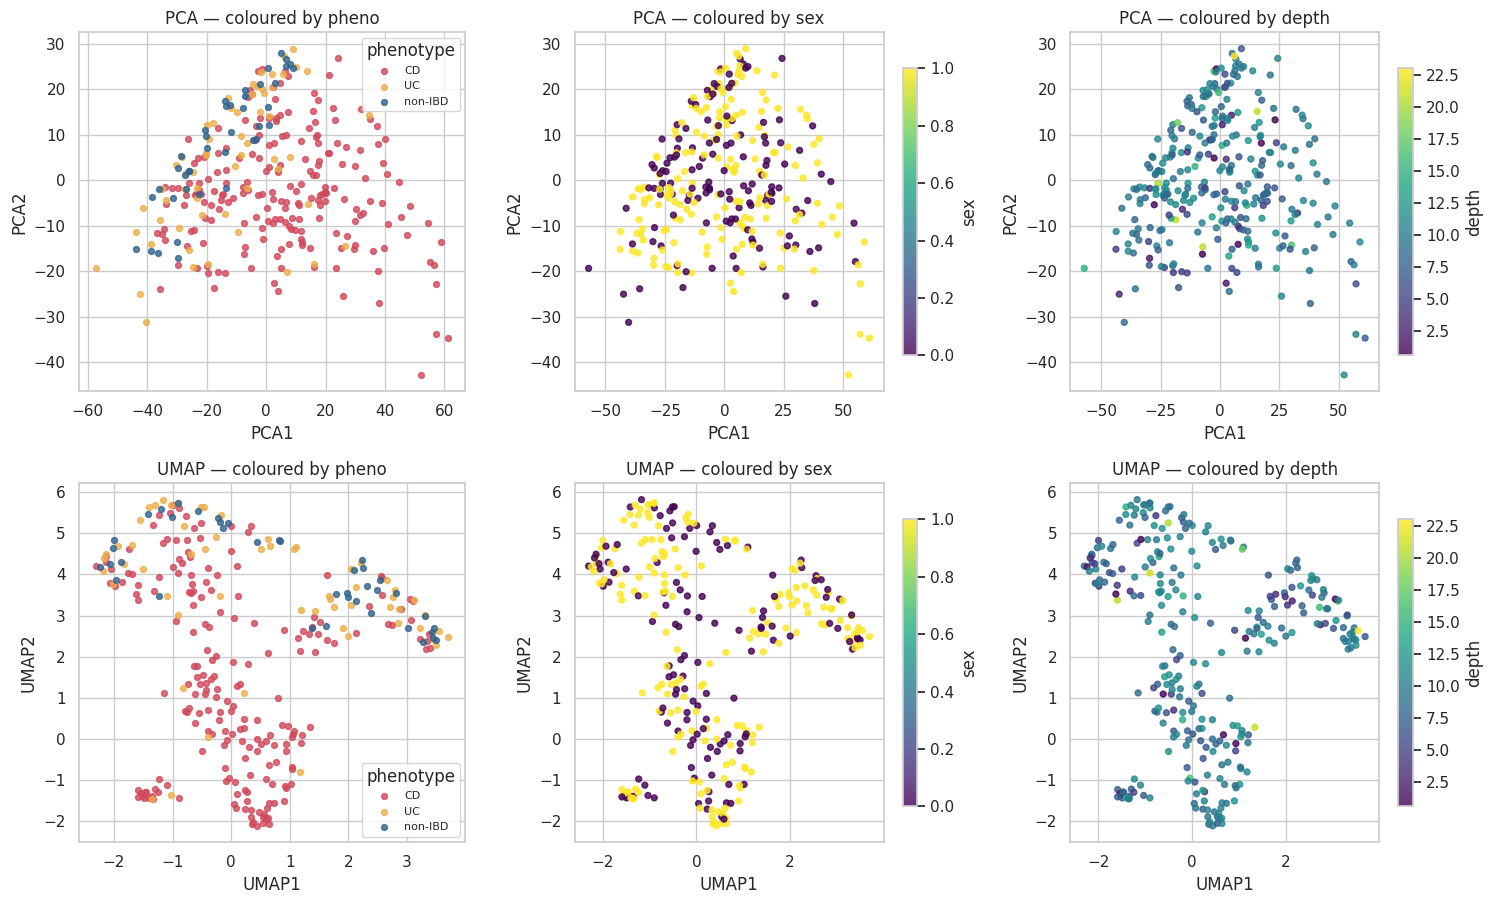

In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Xs = StandardScaler().fit_transform(X)
pcs = PCA(n_components=10, random_state=RNG).fit(Xs)
XP  = pcs.transform(Xs)
print("Variance explained by PC1–5:", (pcs.explained_variance_ratio_[:5]*100).round(1))

emb = {"PCA": XP[:, :2]}
try:
    import umap
    emb["UMAP"] = umap.UMAP(n_components=2, random_state=RNG).fit_transform(XP)
except Exception as e:
    print("UMAP unavailable, showing PCA only:", e)

meta_reset = meta.reset_index(drop=True)
color_by = {"pheno": meta_reset["pheno"].map(PAL),
            "sex":   meta_reset["sex"].astype("category").cat.codes,
            "depth": meta_reset["depth_M"]}

fig, axes = plt.subplots(len(emb), 3, figsize=(15, 4.6*len(emb)), squeeze=False)
for r, (name, coords) in enumerate(emb.items()):
    for c, (cname, cvals) in enumerate(color_by.items()):
        ax = axes[r][c]
        if cname == "pheno":
            for k in ["CD","UC","non-IBD"]:
                m = meta_reset["pheno"].values == k
                ax.scatter(coords[m,0], coords[m,1], s=18, alpha=0.8, c=PAL[k], label=k)
            ax.legend(fontsize=8, title="phenotype")
        else:
            sc = ax.scatter(coords[:,0], coords[:,1], s=18, alpha=0.8, c=cvals, cmap="viridis")
            plt.colorbar(sc, ax=ax, shrink=0.8, label=cname)
        ax.set_title(f"{name} — coloured by {cname}")
        ax.set_xlabel(f"{name}1"); ax.set_ylabel(f"{name}2")
plt.tight_layout(); plt.show()

> **Read-out.** Phenotype produces visible (if overlapping) structure, while sex and depth do
> **not** organise the samples — consistent with 1.2's conclusion that the signal is
> biological, not technical. The overlap between groups (especially UC↔CD) foreshadows that
> the classification task is non-trivial but learnable.

## 1.7. Differential gene expression (DGE)

The most direct test of "is there signal": how many genes are differentially expressed
between groups? We run a Mann-Whitney U test per gene with Benjamini-Hochberg FDR, for each
pairwise contrast.

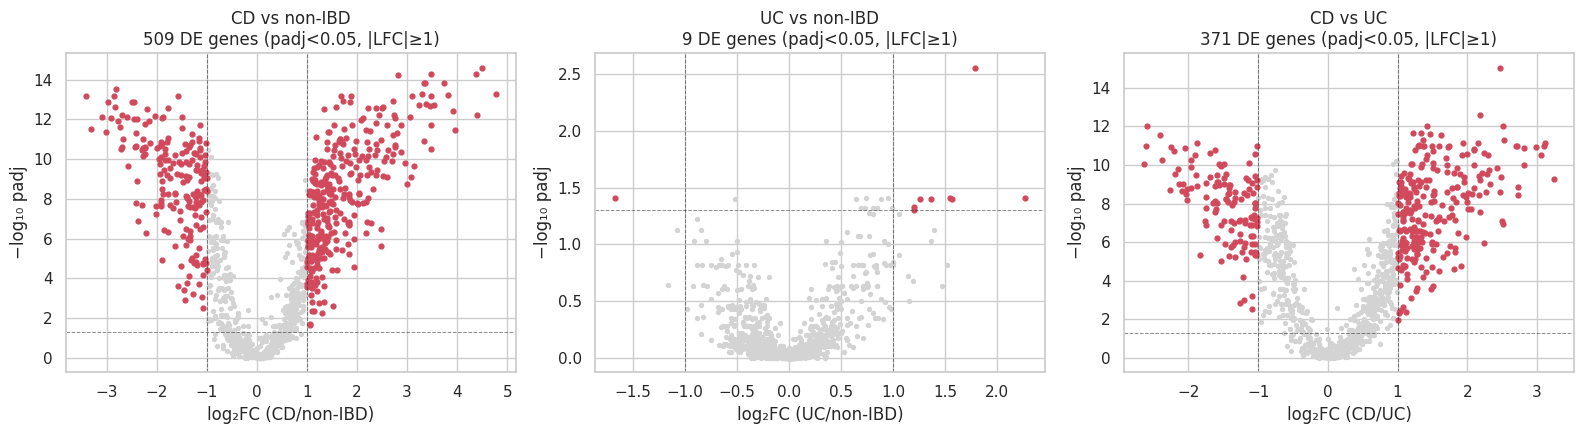

               DE genes (padj<0.05 & |LFC|≥1)  of total genes
CD vs non-IBD                             509            1165
UC vs non-IBD                               9            1165
CD vs UC                                  371            1165


In [11]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

def dge(a_idx, b_idx):
    A, B = X[a_idx], X[b_idx]
    pv = np.array([stats.mannwhitneyu(A[:,j], B[:,j], alternative="two-sided").pvalue
                   for j in range(X.shape[1])])
    padj = multipletests(pv, method="fdr_bh")[1]
    lfc  = A.mean(0) - B.mean(0)            # already log2 space → log2 fold change
    return pd.DataFrame({"gene": genes, "log2fc": lfc, "p": pv, "padj": padj})

idx = {k: np.where(y == v)[0] for v, k in PHENO.items()}
contrasts = {"CD vs non-IBD": ("CD","non-IBD"),
             "UC vs non-IBD": ("UC","non-IBD"),
             "CD vs UC":      ("CD","UC")}

dge_res = {}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name,(a,b)) in zip(axes, contrasts.items()):
    d = dge(idx[a], idx[b]); dge_res[name] = d
    sig = (d["padj"] < 0.05) & (d["log2fc"].abs() >= 1.0)
    ax.scatter(d.loc[~sig,"log2fc"], -np.log10(d.loc[~sig,"padj"].clip(lower=1e-300)),
               s=8, c="lightgrey")
    ax.scatter(d.loc[sig,"log2fc"], -np.log10(d.loc[sig,"padj"].clip(lower=1e-300)),
               s=12, c="#d1495b")
    ax.axhline(-np.log10(0.05), ls="--", c="k", lw=0.7, alpha=0.5)
    ax.axvline(1, ls="--", c="k", lw=0.7, alpha=0.5); ax.axvline(-1, ls="--", c="k", lw=0.7, alpha=0.5)
    ax.set_title(f"{name}\n{int(sig.sum())} DE genes (padj<0.05, |LFC|≥1)")
    ax.set_xlabel(f"log₂FC ({a}/{b})"); ax.set_ylabel("−log₁₀ padj")
plt.tight_layout(); plt.show()

summary = pd.DataFrame({
    name: {"DE genes (padj<0.05 & |LFC|≥1)":
           int(((d["padj"]<0.05)&(d["log2fc"].abs()>=1)).sum()),
           "of total genes": len(genes)}
    for name, d in dge_res.items()}).T
print(summary.to_string())

In [12]:
# Are the top DE genes biologically credible? Map a few to symbols via mygene.
try:
    import mygene
    d = dge_res["CD vs non-IBD"].sort_values("padj")
    top_ids = d.head(15)["gene"].tolist()
    mg = mygene.MyGeneInfo()
    sym = mg.querymany(top_ids, scopes="ensembl.gene", fields="symbol",
                       species="human", as_dataframe=True, verbose=False)["symbol"]
    tbl = d.head(15).copy()
    tbl["symbol"] = tbl["gene"].map(sym.to_dict())
    print("Top 15 DE genes — CD vs non-IBD:")
    print(tbl[["symbol","gene","log2fc","padj"]].to_string(index=False))
except Exception as e:
    print("Symbol mapping skipped (needs network):", e)
    print(dge_res["CD vs non-IBD"].sort_values("padj").head(15).to_string(index=False))

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


Top 15 DE genes — CD vs non-IBD:
 symbol            gene    log2fc         padj
   AQP9 ENSG00000103569  4.503829 2.482501e-15
  CXCL8 ENSG00000169429  4.379381 4.922329e-15
    OSM ENSG00000099985  3.483765 5.464407e-15
 FCGR3A ENSG00000203747  2.815290 6.125134e-15
  PROK2 ENSG00000163421  3.362719 1.537341e-14
 S100A8 ENSG00000143546  3.726930 1.537341e-14
TNFAIP6 ENSG00000123610  3.340669 1.537341e-14
SLC14A2 ENSG00000132874 -2.814409 3.059644e-14
 DUOXA2 ENSG00000140274  4.768185 4.986461e-14
 S100A9 ENSG00000163220  3.306393 5.092484e-14
 FCGR3B ENSG00000162747  3.811018 5.607644e-14
  GDF15 ENSG00000130513  1.682933 6.318489e-14
   MUC1 ENSG00000185499  3.094746 6.318489e-14
 FCGR2A ENSG00000143226  1.878557 6.318489e-14
   FPR2 ENSG00000171049  3.477445 6.318489e-14


> **Verdict (1.7).** Strong, biologically plausible signal for **CD** (≈500 DE genes vs control),
> but a striking asymmetry: **UC vs control yields only a handful of DE genes**, while CD vs UC
> is rich (≈370). In other words, at the single-gene level UC is hard to separate from control
> in this ileal-biopsy cohort — which directly predicts that any classifier (GNN included) will
> struggle most on the UC class. The signal is real, but unevenly distributed across phenotypes.

## 1.8. Baseline classifier — the signal floor the GNN must beat

A GNN is only worth its complexity if it beats a simple model on the same information. We fit
**class-weighted logistic regression** and a **random forest** on the log-CPM matrix with
stratified 5-fold CV, and report *balanced accuracy* and *macro-F1* (imbalance-robust) plus a
confusion matrix.

Logistic (balanced)           balanced_acc=0.729  macroF1=0.714
Random forest (balanced)      balanced_acc=0.526  macroF1=0.544


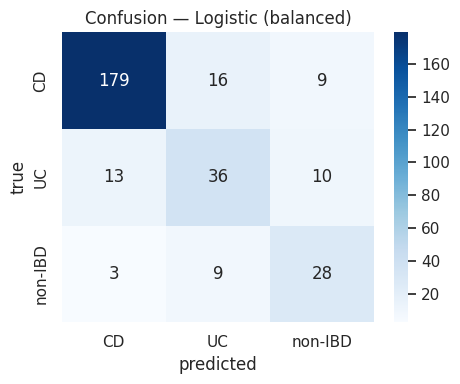

              precision    recall  f1-score   support

          CD       0.92      0.88      0.90       204
          UC       0.59      0.61      0.60        59
     non-IBD       0.60      0.70      0.64        40

    accuracy                           0.80       303
   macro avg       0.70      0.73      0.71       303
weighted avg       0.81      0.80      0.81       303



In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import (balanced_accuracy_score, f1_score,
                             confusion_matrix, classification_report)

cv = StratifiedKFold(5, shuffle=True, random_state=RNG)
models = {
    "Logistic (balanced)": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=3000, class_weight="balanced")),
    "Random forest (balanced)": RandomForestClassifier(
        n_estimators=400, class_weight="balanced", random_state=RNG),
}
preds = {}
for name, clf in models.items():
    p = cross_val_predict(clf, X, y, cv=cv)
    preds[name] = p
    print(f"{name:28s}  balanced_acc={balanced_accuracy_score(y,p):.3f}  "
          f"macroF1={f1_score(y,p,average='macro'):.3f}")

best = max(preds, key=lambda n: balanced_accuracy_score(y, preds[n]))
cm = confusion_matrix(y, preds[best])
fig, ax = plt.subplots(figsize=(4.8, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[PHENO[i] for i in range(3)],
            yticklabels=[PHENO[i] for i in range(3)], ax=ax)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(f"Confusion — {best}")
plt.tight_layout(); plt.show()
print(classification_report(y, preds[best],
                            target_names=[PHENO[i] for i in range(3)]))

> **Verdict (1.8).** A plain linear model reaches **≈0.73 balanced accuracy / ≈0.71 macro-F1**
> from expression alone — well above the ~0.33 chance level for 3 balanced classes. So the
> expression data is unambiguously **good enough to train a classifier**, and this number is
> the bar the GNN must clear to justify itself. Note the minority classes (UC, non-IBD) carry
> most of the error — the imbalance, not lack of signal, is the limiting factor.

---
# Part 2 — Are the sample-specific networks suitable for the GNN?

## 2.1. Graph dataset overview

Each sample is one graph: nodes = genes, node features = `[z-scored expression (1) | ESM-2
embedding (128)]`, edges = LIONESS sample-specific co-expression relationships (typed
positive/negative, weighted).

In [14]:
g0 = graphs[0]
n_nodes = np.array([g.x.shape[0] for g in graphs])
n_edges = np.array([g.edge_index.shape[1] for g in graphs])   # directed (each undirected edge ×2)
feat_dim = g0.x.shape[1]

print(f"Graphs                 : {len(graphs)}")
print(f"Nodes / graph          : min {n_nodes.min()}, max {n_nodes.max()}  (constant = shared PPI backbone)")
print(f"Node-feature dimension : {feat_dim}  (1 expression + {feat_dim-1} ESM-2 embedding)")
print(f"Directed edges / graph : min {n_edges.min()}, max {n_edges.max()}, "
      f"mean {n_edges.mean():.0f} ± {n_edges.std():.0f}")
print(f"Undirected edges       : ~{n_edges.mean()/2:.0f} per graph")
print(f"Graph label attr y     : {sorted(set(int(g.y) for g in graphs))}")

Graphs                 : 303
Nodes / graph          : min 1165, max 1165  (constant = shared PPI backbone)
Node-feature dimension : 129  (1 expression + 128 ESM-2 embedding)
Directed edges / graph : min 11634, max 14914, mean 13460 ± 669
Undirected edges       : ~6730 per graph
Graph label attr y     : [0, 1, 2]


## 2.2. Node-feature audit

The GNN's `input_proj_dim=None` path feeds these 129 features straight into the R-GCN, so
their scaling and non-degeneracy matter. We verify: (a) the expression channel is z-scored,
(b) the embedding block is *static per gene* (identical across graphs — it carries gene
identity, not sample state), and (c) the embedding is not degenerate.

Expression channel : mean 0.000, std 0.998  → z-scored ✓
Embedding block    : identical across graphs? True  (expected True — static ESM-2 gene identity)
Embedding stats    : L2-norm mean 1.000 (unit-normalised), per-dim std mean 0.088


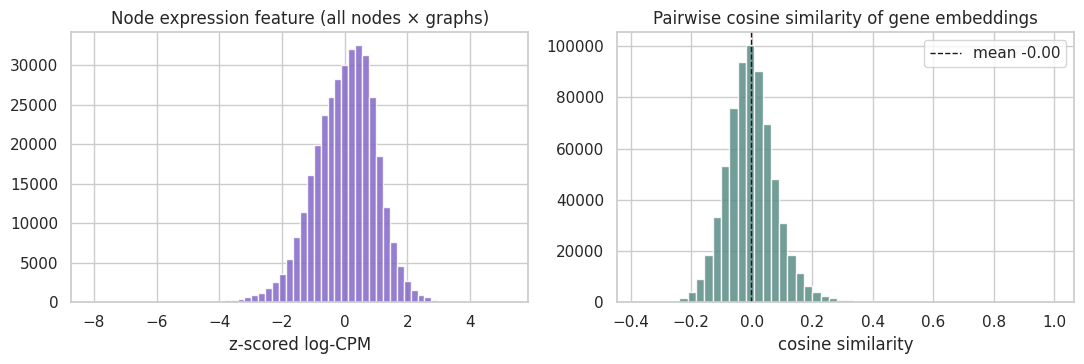

Gene-embedding pairwise cosine: mean -0.000, std 0.087  → genes are well-separated ✓


In [15]:
expr_all = torch.stack([g.x[:, 0] for g in graphs]).numpy()      # [n_graphs, n_nodes]
emb0 = graphs[0].x[:, 1:]
emb_static = all(torch.allclose(g.x[:, 1:], emb0) for g in graphs[:25])

print(f"Expression channel : mean {expr_all.mean():.3f}, std {expr_all.std():.3f}  "
      f"→ {'z-scored ✓' if abs(expr_all.mean())<0.05 and abs(expr_all.std()-1)<0.1 else 'NOT standardized ⚠'}")
print(f"Embedding block    : identical across graphs? {emb_static}  "
      f"(expected True — static ESM-2 gene identity)")
print(f"Embedding stats    : L2-norm mean {emb0.norm(dim=1).mean():.3f} (unit-normalised), "
      f"per-dim std mean {emb0.std(dim=0).mean():.3f}")

# Are the gene embeddings actually distinct, or collapsed? Look at the spread of
# pairwise cosine similarities: a tight peak near 1 would mean degenerate identities.
from sklearn.metrics.pairwise import cosine_similarity as _cos
E = emb0.numpy()
Csub = _cos(E)
offdiag = Csub[np.triu_indices_from(Csub, k=1)]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(expr_all.ravel(), bins=60, color="#8367c7", alpha=0.85)
axes[0].set_title("Node expression feature (all nodes × graphs)")
axes[0].set_xlabel("z-scored log-CPM")
axes[1].hist(offdiag, bins=50, color="#5b8c85", alpha=0.85)
axes[1].axvline(offdiag.mean(), color="k", ls="--", lw=1, label=f"mean {offdiag.mean():.2f}")
axes[1].set_title("Pairwise cosine similarity of gene embeddings")
axes[1].set_xlabel("cosine similarity"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"Gene-embedding pairwise cosine: mean {offdiag.mean():.3f}, "
      f"std {offdiag.std():.3f}  → genes are {'well-separated ✓' if offdiag.std()>0.05 else 'near-degenerate ⚠'}")

> **Read-out.** Expression is correctly z-scored (mean≈0, std≈1) and the embedding block is
> static per gene with unit-ish norm — features are on comparable scales, so no single channel
> will dominate the first-layer gradients. One consequence worth remembering: because the
> embeddings are identical across every graph, **all between-sample signal lives in the single
> expression channel and in the edge weights** — the 128 embedding dims only encode *which
> gene* a node is.

## 2.3. Graph-size statistics by phenotype

Do the networks differ in gross size across phenotypes? Large systematic differences would
mean the GNN could classify from edge count alone (a shortcut, not biology).

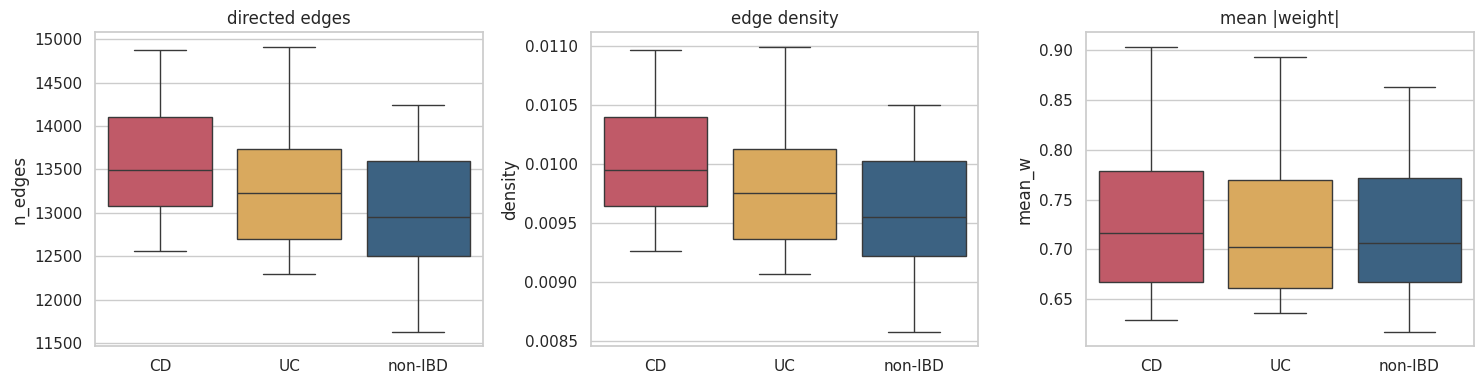

         n_edges  density  pos_frac  mean_w
pheno                                      
CD       13488.0   0.0099    0.8234  0.7166
UC       13228.0   0.0098    0.8325  0.7026
non-IBD  12956.0   0.0096    0.8100  0.7062


In [16]:
gstats = pd.DataFrame({
    "pheno": pheno,
    "n_edges": n_edges,
    "density": n_edges / (n_nodes*(n_nodes-1)),                 # directed density
    "pos_frac": [ (g.edge_type==0).float().mean().item() for g in graphs ],
    "mean_w":   [ g.edge_attr.mean().item() for g in graphs ],
})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, ttl in zip(axes, ["n_edges","density","mean_w"],
                        ["directed edges","edge density","mean |weight|"]):
    sns.boxplot(data=gstats, x="pheno", y=col, order=["CD","UC","non-IBD"],
                palette=PAL, ax=ax)
    ax.set_title(ttl); ax.set_xlabel("")
plt.tight_layout(); plt.show()

print(gstats.groupby("pheno")[["n_edges","density","pos_frac","mean_w"]]
      .median().reindex(["CD","UC","non-IBD"]).round(4).to_string())

## 2.4. Edge sign & weight distribution

The R-GCN uses two relations (positive vs negative co-expression). We check the balance and
the weight distribution the edge-predictor is asked to regress.

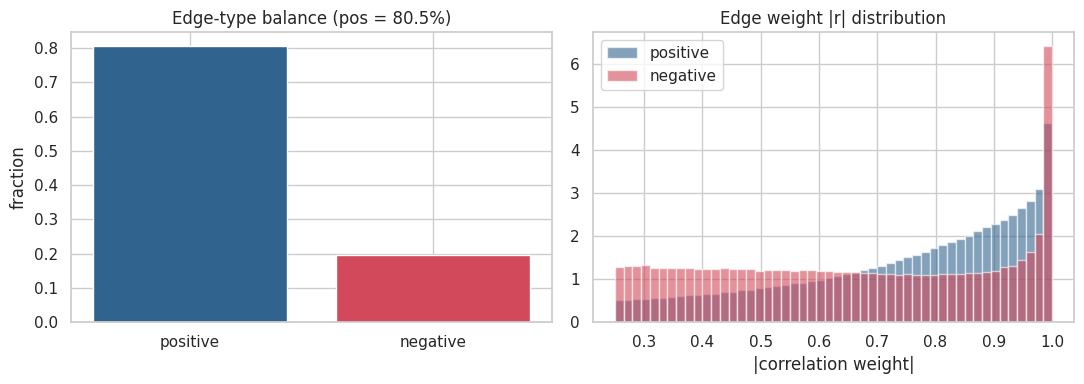

Global positive-edge fraction : 80.5%
Weight |r|: min 0.250, median 0.776, max 1.000
(Threshold used by LIONESS was 0.25 → all |r| ≥ 0.25 as expected.)


In [17]:
all_w   = np.concatenate([g.edge_attr.numpy() for g in graphs])
all_typ = np.concatenate([g.edge_type.numpy() for g in graphs])
pos_frac_global = (all_typ == 0).mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(["positive","negative"], [ (all_typ==0).mean(), (all_typ==1).mean() ],
            color=["#30638e","#d1495b"])
axes[0].set_title(f"Edge-type balance (pos = {pos_frac_global:.1%})"); axes[0].set_ylabel("fraction")
axes[1].hist(all_w[all_typ==0], bins=50, alpha=0.6, label="positive", color="#30638e", density=True)
axes[1].hist(all_w[all_typ==1], bins=50, alpha=0.6, label="negative", color="#d1495b", density=True)
axes[1].set_title("Edge weight |r| distribution"); axes[1].set_xlabel("|correlation weight|")
axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Global positive-edge fraction : {pos_frac_global:.1%}")
print(f"Weight |r|: min {all_w.min():.3f}, median {np.median(all_w):.3f}, max {all_w.max():.3f}")
print(f"(Threshold used by LIONESS was 0.25 → all |r| ≥ 0.25 as expected.)")

> **Read-out.** ~80% of edges are positive; the negative relation is the minority stream in
> every R-GCN layer, which is fine but means the `conv_neg` branch sees less signal. All
> weights sit above the 0.25 LIONESS threshold with a right-skewed distribution — a reasonable,
> non-degenerate target for the edge-predictor MSE loss.

## 2.5. Topology — shared backbone, degree, isolated nodes

All graphs are thresholded subsets of the same STRING PPI backbone. We quantify how shared the
topology really is (edge-set Jaccard between random graph pairs), the degree distribution, and
— importantly — how many nodes end up **isolated** (no edges → they receive no message passing
and only contribute their raw features through mean-pooling).

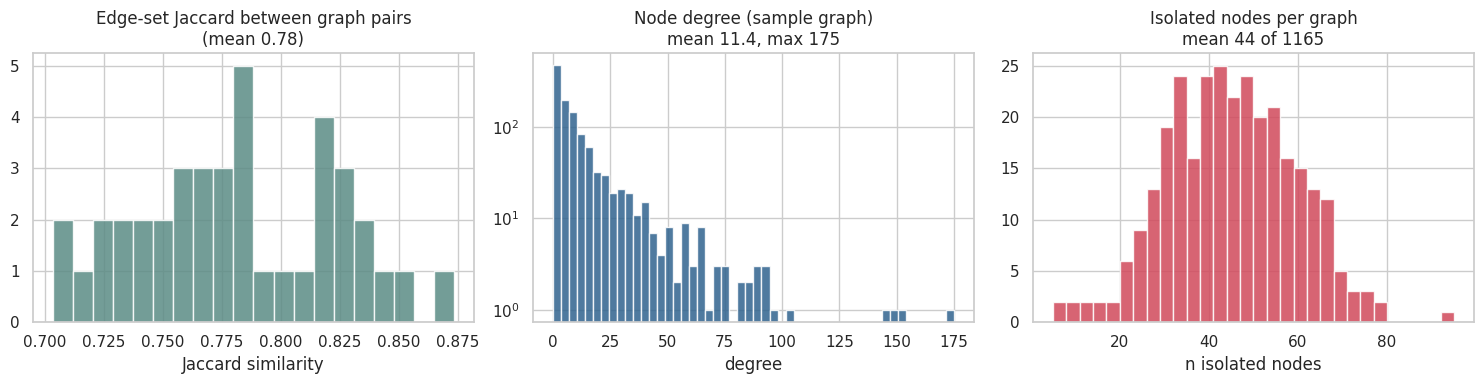

Mean pairwise edge-set Jaccard : 0.78  → topology is largely shared
Isolated nodes per graph       : 44 ± 14 (4% of 1165 nodes)
Degree (sample graph)          : mean 11.4, max 175 (hub genes present)


In [18]:
import networkx as nx

def undirected_edge_set(g):
    ei = g.edge_index.numpy()
    return {(min(a,b), max(a,b)) for a,b in ei.T}

rng = np.random.default_rng(RNG)
pairs = rng.integers(0, len(graphs), size=(40, 2))
jacc = []
for i, j in pairs:
    if i == j: continue
    A, B = undirected_edge_set(graphs[i]), undirected_edge_set(graphs[j])
    jacc.append(len(A & B) / len(A | B))
jacc = np.array(jacc)

# Degree & isolated-node stats on a representative graph
deg_per_graph = []
iso_per_graph = []
for g in graphs:
    deg = np.bincount(g.edge_index[0].numpy(), minlength=g.x.shape[0])  # out-degree (=in, undirected)
    deg_per_graph.append(deg)
    iso_per_graph.append(int((deg == 0).sum()))
deg_rep = deg_per_graph[0]
iso_arr = np.array(iso_per_graph)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(jacc, bins=20, color="#5b8c85", alpha=0.85)
axes[0].set_title(f"Edge-set Jaccard between graph pairs\n(mean {jacc.mean():.2f})")
axes[0].set_xlabel("Jaccard similarity")
axes[1].hist(deg_rep, bins=50, color="#30638e", alpha=0.85)
axes[1].set_title(f"Node degree (sample graph)\nmean {deg_rep.mean():.1f}, max {deg_rep.max()}")
axes[1].set_xlabel("degree"); axes[1].set_yscale("log")
axes[2].hist(iso_arr, bins=30, color="#d1495b", alpha=0.85)
axes[2].set_title(f"Isolated nodes per graph\nmean {iso_arr.mean():.0f} of {n_nodes[0]}")
axes[2].set_xlabel("n isolated nodes")
plt.tight_layout(); plt.show()

print(f"Mean pairwise edge-set Jaccard : {jacc.mean():.2f}  → topology is largely shared")
print(f"Isolated nodes per graph       : {iso_arr.mean():.0f} ± {iso_arr.std():.0f} "
      f"({iso_arr.mean()/n_nodes[0]:.0%} of {n_nodes[0]} nodes)")
print(f"Degree (sample graph)          : mean {deg_rep.mean():.1f}, max {deg_rep.max()} "
      f"(hub genes present)")

> **Read-out.** The backbone is largely shared (high Jaccard) with per-sample edges toggling
> on/off around the threshold — so what varies between samples is mostly *edge weights*, not
> topology. A non-trivial fraction of nodes can be isolated in a given graph; those contribute
> only their (static embedding + one expression scalar) through mean-pooling. The degree
> distribution is heavy-tailed (hub genes), typical of PPI-derived graphs.

## 2.6. How discriminative are the networks *on their own*?

If we hand a classifier only cheap graph-topology summaries (edge count, density, positive
fraction, mean weight, mean/std of the shared-edge weight vector), how well can it separate
phenotypes? This isolates the contribution of the *network structure* from the node features.

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

# Build a weight matrix over edges present in ≥95% of graphs (signed weight)
from collections import Counter
def signed_dict(g):
    ei = g.edge_index.numpy(); w = g.edge_attr.numpy()
    sgn = np.where(g.edge_type.numpy()==0, 1.0, -1.0) * w
    d = {}
    for k in range(ei.shape[1]):
        a, b = ei[0,k], ei[1,k]
        if a < b: d[(a,b)] = sgn[k]
    return d
sdicts = [signed_dict(g) for g in graphs]
cnt = Counter(); [cnt.update(d.keys()) for d in sdicts]
common = [e for e,c in cnt.items() if c >= int(0.95*len(graphs))]
W = np.array([[d.get(e, 0.0) for e in common] for d in sdicts])   # [n_graphs, n_common_edges]
print(f"Common edges (≥95% of graphs): {len(common)}  → weight matrix {W.shape}")

Xg = np.c_[gstats["n_edges"], gstats["density"], gstats["pos_frac"],
           gstats["mean_w"], W.mean(1), W.std(1)]
p_topo = cross_val_predict(
    RandomForestClassifier(400, class_weight="balanced", random_state=RNG),
    Xg, y, cv=cv)
print(f"RF on graph-topology summaries : balanced_acc={balanced_accuracy_score(y,p_topo):.3f}  "
      f"macroF1={f1_score(y,p_topo,average='macro'):.3f}")
print(f"(Compare with expression-only baseline from 1.8.)")

Common edges (≥95% of graphs): 2011  → weight matrix (303, 2011)
RF on graph-topology summaries : balanced_acc=0.561  macroF1=0.601
(Compare with expression-only baseline from 1.8.)


> **Read-out.** Crude topology summaries are only **weakly** discriminative (well below the
> expression baseline). Interpretation: the phenotype signal the GNN exploits comes
> *predominantly from the node expression channel*; the network acts as a biologically-informed
> **message-passing prior / smoother**, not as a standalone classifier. That is a legitimate
> design — but it means the network's value must be demonstrated as *improvement over the
> expression baseline*, not assumed.

## 2.7 · ⚠ Label-leakage check — networks are built *per phenotype group*

This is the most important methodological caveat. In the tutorial, `get_corr_matrix(...,
group_by="source_name")` builds a **separate aggregate correlation network `G` for each
phenotype group**, and LIONESS then derives every sample's network as a leave-one-out
perturbation of *its own group's* `G`. Consequently, samples from the same class share a
common backbone **by construction** — some class information can leak into the graph weights
independently of biology. We measure it: within-group vs between-group similarity of the
shared-edge weight vectors.

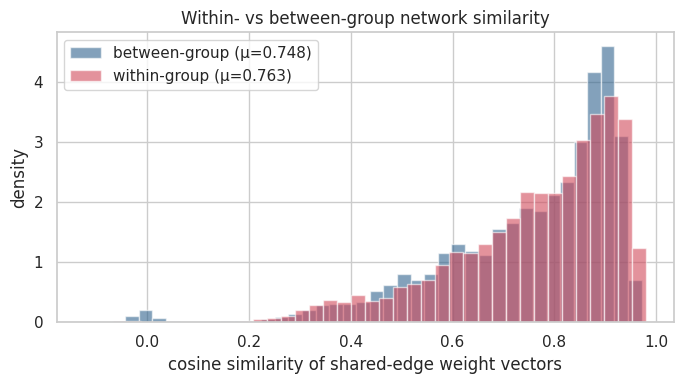

within-group  mean cosine : 0.763
between-group mean cosine : 0.748
gap (leakage indicator)   : +0.014


In [20]:
S = cosine_similarity(W)
within, between = [], []
for i in range(len(graphs)):
    for j in range(i+1, len(graphs)):
        (within if y[i]==y[j] else between).append(S[i,j])
within, between = np.array(within), np.array(between)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(between, bins=40, alpha=0.6, density=True, label=f"between-group (μ={between.mean():.3f})", color="#30638e")
ax.hist(within,  bins=40, alpha=0.6, density=True, label=f"within-group (μ={within.mean():.3f})", color="#d1495b")
ax.set_xlabel("cosine similarity of shared-edge weight vectors")
ax.set_ylabel("density"); ax.set_title("Within- vs between-group network similarity")
ax.legend()
plt.tight_layout(); plt.show()

print(f"within-group  mean cosine : {within.mean():.3f}")
print(f"between-group mean cosine : {between.mean():.3f}")
print(f"gap (leakage indicator)   : {within.mean()-between.mean():+.3f}")

> **Verdict (2.7).** Networks are only **marginally** more similar within a class than across
> classes — the per-group construction introduces a *small* circular bias rather than a
> catastrophic one (most of the ~0.75 similarity is the shared PPI backbone common to all
> samples). Still, it is a real bias, and it interacts badly with a *random* train/test split:
> the aggregate `G` for each class is computed over train **and** test samples, so a test
> sample's graph is partly informed by its class's training samples.
>
> **Recommendations:**
> 1. Build the LIONESS background `G` on **all samples jointly** (not per group), so the graph
>    construction is blind to the label; or
> 2. If per-group construction is kept, compute `G` on the **training split only** and evaluate
>    with **group-aware / nested CV** to get an honest generalisation estimate;
> 3. Always report the GNN against the expression-only baseline from §1.8 to prove the graph
>    adds value beyond what leaks in.

## 2.8 · Split feasibility & training implications

With only ~40 controls, a stratified 80/20 split leaves very few minority-class graphs in the
test set — enough to train, but test-set metrics on minority classes will be high-variance.

In [22]:
from sklearn.model_selection import train_test_split
tr, te = train_test_split(np.arange(len(graphs)), test_size=0.2,
                          random_state=RNG, stratify=y)
split = pd.DataFrame({
    "train": pd.Series(pheno[tr]).value_counts().reindex(["CD","UC","non-IBD"]),
    "test":  pd.Series(pheno[te]).value_counts().reindex(["CD","UC","non-IBD"]),
})
print(split.to_string())
print(f"\nMinority (non-IBD) test graphs: {split.loc['non-IBD','test']} "
      f"→ each misclassification moves test recall by ~{100/split.loc['non-IBD','test']:.0f} pts.")
print("Recommendation: report k-fold CV (not a single split), use class-weighted loss, "
      "and prefer balanced-accuracy / macro-F1 over accuracy.")

         train  test
CD         163    41
UC          47    12
non-IBD     32     8

Minority (non-IBD) test graphs: 8 → each misclassification moves test recall by ~12 pts.
Recommendation: report k-fold CV (not a single split), use class-weighted loss, and prefer balanced-accuracy / macro-F1 over accuracy.


---
# 3 · Consolidated verdict & recommendations

### Concern 1 — Is the gene-expression data good enough for a classifier / regressor?

**Yes, for classification.**

- **Signal is present and biological.** ≈500 DE genes for CD vs control (and ≈370 CD vs UC),
  phenotype visible in unsupervised PCA/UMAP, and a class-weighted linear baseline reaches
  **≈0.73 balanced accuracy / ≈0.71 macro-F1** — far above chance.
- **But the signal is uneven.** UC vs control produces only a handful of DE genes, so **UC is the
  hardest class**; expect most classifier error to concentrate there, and interpret UC-specific
  GNN/SAE features with extra caution.
- **No technical confounding.** Single instrument/center/tissue/library, comparable depth and
  age across groups; clean QC with no samples to drop.
- **Main limitation: class imbalance (204 / 59 / 40) and small N (303).** Use stratified splits,
  class-weighted loss, and imbalance-robust metrics. Accuracy alone is misleading.
- **Regression:** there is no strong continuous target; `age_at_diagnosis` is weakly predictable
  at best. The dataset's natural task is **phenotype classification**, not regression.

### Concern 2 — Are the sample-specific networks suitable for the GNN?

**Usable, with one methodological fix and honest evaluation.**

- **Well-formed graphs.** Constant 1,165-node shared PPI backbone, ~6.7k undirected edges/graph,
  correctly z-scored expression features, static valid ESM-2 embeddings, non-degenerate weights,
  sensible degree distribution. Nothing structurally broken.
- **Topology is largely shared; between-sample variation is mostly edge weights.** Crude topology
  summaries are only weakly discriminative → the GNN's classification signal comes mainly from
  the **node expression channel**, with the network acting as a message-passing prior.
- **⚠ Per-group LIONESS construction leaks a small amount of label information** into the graph
  weights and, combined with a random split, lets test graphs "see" their class's background.
  The effect measured here is small but real.

**Actionable recommendations**
1. Build the LIONESS background on **all samples jointly**, or on **training-only** data, so
   graph construction is label-blind; evaluate with **group-aware / nested CV**.
2. Always benchmark the GNN against the **expression-only baseline (§1.8)** — the graph must beat
   ≈0.73 balanced accuracy to justify its complexity.
3. Handle imbalance explicitly. The GNN currently uses an **unweighted** `nn.CrossEntropyLoss()`
   (see `GraphClassifier` in `gea.py`) — pass `weight=` inversely proportional to class frequency,
   use stratified k-fold, and report macro-F1 / balanced accuracy / per-class recall rather than
   raw accuracy.
4. Consider whether the minority classes have enough graphs for the SAE interpretability step to
   be stable (DFA on ~40 controls is low-powered).